# 4. Vessel labelling with a graph neural network

Each centerline segment gets an anatomical name (aorta, brachiocephalic trunk, left common carotid...). The segments form a graph, the graph is described with a handful of geometric features per segment, and a graph neural network predicts the name of every segment at once.

This starts from the segments array produced in notebook 2 and takes seconds on a GPU.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from arterial_nb import *
from arterial.io.load_and_save_operations import load_json
from arterial import model_registry
from arterial.vessel_labelling.vessel_labeller import VesselLabeller
from arterial.vessel_labelling.utils import node_transform

labeller = VesselLabeller(case("labelling"), MODE, derived("centerline_segments_array.npy"))
with quiet():
    labeller.build_segments_graph(save=True)
graph = labeller.segments_graph
print(f"{graph.number_of_nodes()} bifurcations/ends, {graph.number_of_edges()} segments")


Arterial framework for automated characterization of vascular tortuosity.
Copyright 2022-2026 Vall d'Hebron Research Institute (VHIR) and Universitat de Barcelona (UB), Barcelona, Spain.
Code licensed under the PolyForm Noncommercial License 1.0.0. Noncommercial use only.



31 bifurcations/ends, 28 segments


## The segments graph

Nodes are the ends of the segments; two segments that meet share a node. Every edge carries its whole coordinate array and 24 features computed from it.

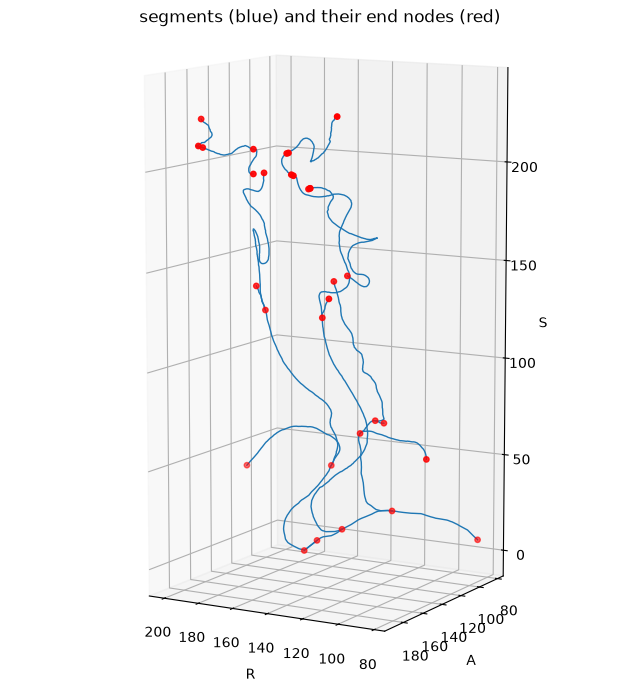

In [2]:
fig = plt.figure(figsize=(8, 9)); ax = fig.add_subplot(111, projection="3d")
for src, dst, data in graph.edges(data=True):
    c = data["coordinate_array"]; ax.plot(c[:, 0], c[:, 1], c[:, 2], color="C0", linewidth=1)
pos = np.array([graph.nodes[n]["pos"] for n in graph]); ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], color="red", s=15)
finish_3d(ax, title="segments (blue) and their end nodes (red)");

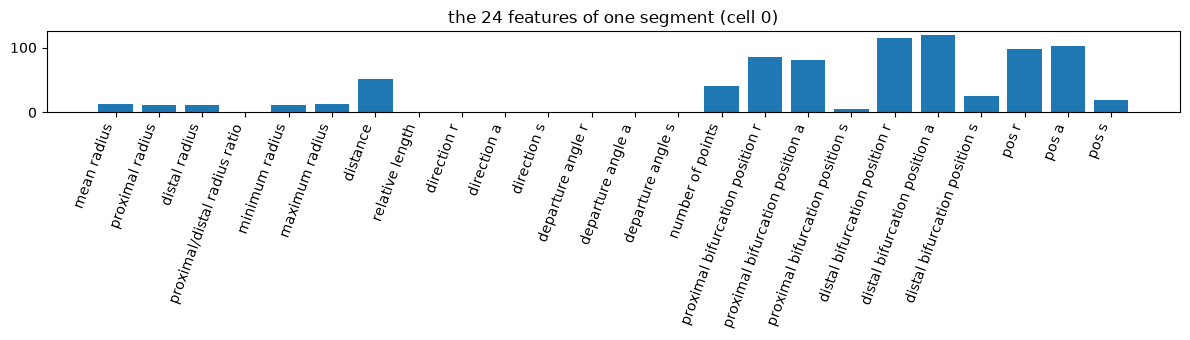

In [3]:
src, dst, data = next(iter(graph.edges(data=True)))
features = data["features_dict"]
plt.figure(figsize=(12, 3.5)); plt.bar(list(features), [float(v) for v in features.values()]); plt.xticks(rotation=70, ha="right"); plt.title(f"the 24 features of one segment (cell {data['cell_id']})"); plt.tight_layout()

The features describe each segment on its own (radii, length, straightness) and its direction in the body (where it points, where it departs from the bifurcation). Nothing about neighbours yet: that is the network's job.

## From edges to nodes

Graph networks predict on nodes, but here the things to name are the edges. The graph is therefore transformed: every segment becomes a node, and two segments that touch become connected.

In [4]:
node_graph = node_transform(graph)
print(f"transformed graph: {node_graph.number_of_nodes()} nodes (segments), {node_graph.number_of_edges()} edges (segments that touch)")

transformed graph: 28 nodes (segments), 37 edges (segments that touch)


## Prediction

The network is a graph attention model trained on labelled cases. A single model gives one answer; the ensemble averages five models trained on different folds, which is what the pipeline uses. The class list comes with the weights.

In [5]:
labels = load_json(model_registry.model_path("vessel_labelling", "extracranial_vessels", "dataset.json"))["edge_labels_dict"]
print("classes:", ", ".join(f"{k}={v}" for k, v in labels.items()))

classes: 0=other, 1=AA, 2=BT, 3=RCCA, 4=LCCA, 5=RSA, 6=LSA, 7=RVA, 8=LVA, 9=RICA, 10=LICA, 11=RECA, 12=LECA, 13=BA


In [6]:
with timed("single model"), quiet():
    labeller.predict_vessel_types(ensemble=False, save=False)
single = {d["cell_id"]: d["vessel_type_name"] for _, _, d in labeller.segments_graph_pred.edges(data=True)}
with timed("ensemble of 5"), quiet():
    labeller.predict_vessel_types(ensemble=True, save=True)
ensemble = {d["cell_id"]: d["vessel_type_name"] for _, _, d in labeller.segments_graph_pred.edges(data=True)}
differ = [cid for cid in sorted(single) if single[cid] != ensemble[cid]]
print(f"{len(differ)} of {len(single)} segments differ between the single model and the ensemble")
for cid in differ:
    print(f"  segment {cid}: single model says {single[cid]}, ensemble says {ensemble[cid]}")

single model: 0.4 s
ensemble of 5: 0.1 s
0 of 28 segments differ between the single model and the ensemble


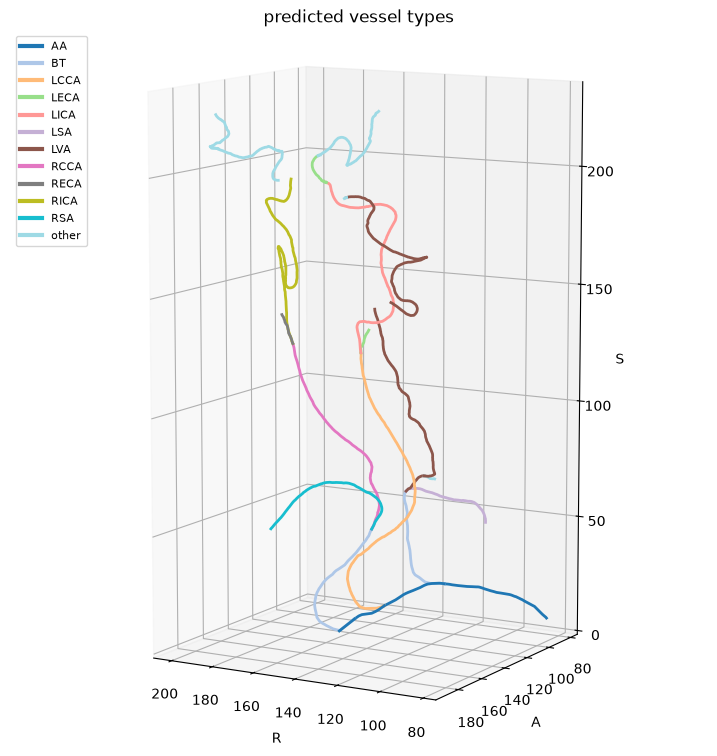

In [7]:
pred = labeller.segments_graph_pred
names = sorted({d["vessel_type_name"] for _, _, d in pred.edges(data=True)})
cmap = plt.get_cmap("tab20"); color = {n: cmap(i / max(1, len(names) - 1)) for i, n in enumerate(names)}
fig = plt.figure(figsize=(9, 10)); ax = fig.add_subplot(111, projection="3d")
for _, _, d in pred.edges(data=True):
    c = d["coordinate_array"]; ax.plot(c[:, 0], c[:, 1], c[:, 2], color=color[d["vessel_type_name"]], linewidth=2)
ax.legend(handles=[plt.Line2D([], [], color=color[n], label=n, linewidth=3) for n in names], loc="upper left", fontsize=8)
finish_3d(ax, title="predicted vessel types");

The pipeline saves the same result as `segments_graph_pred.png`, drawn with the package's own plotting function (coronal projection, patient right on the left).

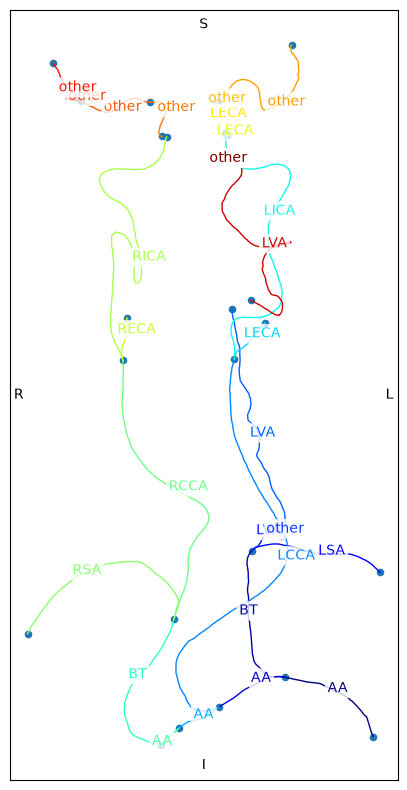

In [8]:
from arterial.vessel_labelling.utils import make_graph_plot
make_graph_plot(pred, label="vessel_type_name", show=True)

## What to check

- The aorta (AA) should be one long segment at the bottom with the three great vessels leaving it.
- Left and right are easy to confuse when a case is mirrored; check that LCCA is on the left of the image in RAS.
- Segments that the single model and the ensemble disagree on are the uncertain ones; the plots saved by `predict_vessel_types(save=True)` help review them.